
## STOCHASTIC MODELING
MODULE 7 | LESSON 3


---

# **Scale-free Networks**

|  |  |
|:---|:---|
|**Reading Time** |  45 minutes |
|**Prior Knowledge** | Random Networks, Erdos-Renyi model |
|**Keywords** | Scale-free networks, preferential attachment, Barabasi-Albert model 


---

In the previous lesson, we learned that **Erdős–Rényi (ER) random networks** provide a useful benchmark for understanding connectivity and randomness.

However, when researchers began mapping *real networks* — social, biological, technological, and financial — they noticed key discrepancies:

1. **Heterogeneous connectivity:**  
   - In real systems, a few nodes (called **hubs**) have *many more connections* than others.  
   - ER networks, in contrast, predict that most nodes have similar degrees.

2. **Heavy-tailed degree distributions:**  
   - Real networks exhibit degree distributions that decay slowly — often following a **power law**, not a Poisson form.

3. **Robust yet fragile behavior:**  
   - These networks are resilient to random failures (removing small nodes) but extremely vulnerable if hubs fail.

In finance, this structure is particularly relevant:
- A few **systemically important institutions** (major banks, funds, clearing houses) are linked to many others.  
- Their central position makes them vital for liquidity and information flow — but also potential points of contagion.

This observation motivated the study of **scale-free networks**.

## **1. Scale-Free Networks**

A **scale-free network** is characterized by a **power-law degree distribution**:

$$
P(k) \sim k^{-\gamma}, \quad \text{typically } 2 < \gamma < 3
$$

This means that:
- Most nodes have few links,  
- But a small number of nodes (hubs) have a disproportionately large number of connections.

\
Unlike in random networks, there is **no typical scale** for the degree — hence the term *scale-free*.

\
Power-law degree distributions have been observed in many complex systems:

| Domain | Example | Interpretation |
|--------|----------|----------------|
| **Internet** | Autonomous systems connected by routers | Few highly connected backbone nodes |
| **Social** | Followers in online networks | Influencers vs typical users |
| **Biological** | Protein interaction networks | Essential proteins interacting with many others |
| **Financial** | Interbank lending, stock correlations, fund holdings | Systemic hubs connecting large portions of the system |

In all these cases, the same property emerges:  A small fraction of nodes concentrates most of the connections, creating a **hub-dominated structure**.

This implies that the probability of observing a node with degree much larger than the mean (i.e., **hub**) remains significant even as the network grows.  

As a result, **scale-free networks are highly heterogeneous**, fundamentally different from the homogeneous randomness of Erdős–Rényi graphs.


## **2. The Barabási–Albert (BA) Model**


The **Barabási–Albert (BA)** model (1999) explains how *scale-free networks* can emerge naturally from two simple mechanisms:

1. **Growth:**  
   The network expands over time — new nodes keep joining.

2. **Preferential attachment:**  
   New nodes are more likely to connect to **already well-connected nodes**.

This reflects the principle of *“the rich get richer”* or *cumulative advantage*.**

### 2.1. Model definition 

Start with a small seed network of $m_0$ nodes, fully connected.  
At each time step $t$:

1. A new node $v_t$ is added.
2. It forms $m \leq m_0$ links to existing nodes. (**growth property**)
3. The probability that it connects to an existing node $i$ is proportional to its degree $k_i$ (**preferential attachment**):

$$
\Pi(k_i) = \frac{k_i}{\sum_j k_j}
$$

This means that highly connected nodes attract new connections more easily.


### 2.2 Expected Degree Growth

Let $k_i(t)$ be the degree of node $i$ at time $t$. At each time step, node $i$’s expected degree increase is given by:

$$
\frac{d k_i}{d t} = m \, \Pi_i = m \cdot \frac{k_i}{\sum_j k_j}
$$

Each new node adds $m$ edges, contributing $2m$ degree units to the network. After $t$ steps, the total degree would be:

$$
\sum_j k_j = 2 m t
$$

And, hence:

$$
\frac{d k_i}{d t} = m \cdot \frac{k_i}{2mt}= \frac{k_i}{2t}
$$

\
This means that the growth rate of a node's degree is:

- proportional to its current degree $k_i$ (as in a 'richer-get-richer' paradigm), and
- inversely proportional to the current age $t$ (growth slows as network gets bigger). 


\
**Solving for $k_i(t)$:**

The next step is to obtain an expression for the degree of a given node $i$ at a given time $t$. That is, the number of connections a node has at a given moment in time. 

In order to derive $k_i(t)$, we start from the previous expression: 

$$
\frac{1}{k_i} \, d k_i = \frac{1}{2t} \, d t
$$


\
When node $i$ joins the network at time $t_i$, it has degree $k_i(t_i) = m$. At the current time $t$, its degree is $k_i(t)$. We can then integrate both sides over these intervals:

$$
\int_{m}^{k_i(t)} \frac{d k'}{k'} = \frac{1}{2} \int_{t_i}^{t} \frac{d t'}{t'}
$$

\
Both of these integrals yield logarithms:

$$
\ln k_i(t) - \ln m = \frac{1}{2} (\ln t - \ln t_i)
$$

which simplify to:
$$
\ln \frac{k_i(t)}{m} = \frac{1}{2} \ln \frac{t}{t_i}
$$

and, using exponents on both sides:

$$
\frac{k_i(t)}{m} = \left( \frac{t}{t_i} \right)^{1/2}
$$

$$
\Rightarrow \quad k_i(t) = m \left( \frac{t}{t_i} \right)^{1/2}
$$

\
As time increases, $t / t_i$ grows, and so does $k_i(t)$. Nodes that joined earlier (smaller $t_i$) accumulate links faster, becoming **hubs**. This result shows that **degree grows as the square root of network age**, capturing the “**rich-get-richer**” dynamic that drives the formation of hubs in the Barabási–Albert model.


### 2.3. Degree distribution

So, given the growth dynamics of the network, **what's the probability that a chosen node has degree $k$?**

To answer this question we need to know the degree distribution, $P(k)$. 

**From $k_i(t)$ to P(k)**:

We already know that:

$$
k_i(t) = m \left( \frac{t}{t_i} \right)^{1/2}
$$

Hence,

$$
t_i = m^2t/k^2
$$

Nodes are added **uniformly** over time, one per step, so "birth times" are uniformly distributed in the interval $[1,t]$:

$$
P(t_i) = \frac{1}{t}
$$

We can use a **change of variable** here, using the probability conservation equation:

$$
P(k)dk = P(t_i)dt_i
$$

Then, since we know $t_i = m^2t/k^2$, we can easily get:

$$
\frac{d t_i}{d k} = - \frac{2 m^2 t}{k^3}
$$

Since $t_i$ decreases as $k$ increases, we take the absolute value:

$$
\left| \frac{d t_i}{d k} \right| = \frac{2 m^2 t}{k^3}
$$

Substitute this result into the probability conservation equation:

$$
P(k) = P(t_i) \, \left| \frac{d t_i}{d k} \right|
$$

Using $P(t_i) = \frac{1}{t}$ (nodes are added uniformly in time), we obtain:

$$
P(k) = \frac{1}{t} \cdot \frac{2 m^2 t}{k^3} = \frac{2 m^2}{k^3}
$$

Thus, the degree distribution follows a **power law**:

$$
P(k) \propto k^{-3}
$$



\
**In a nutshell, the BA model offers some interesting features:**


| Property |  |
|-----------|-----------|
| **Degree distribution** | $P(k) \sim k^{-3}$ |
| **Clustering coefficient** | $ C(k) \sim k^{-1} $ (high-degree nodes cluster less) |
| **Average path length** | $ L \sim \frac{\ln n}{\ln \ln n} $ (very small) |
| **Presence of hubs** | A few nodes accumulate a large fraction of edges |



\
These properties imply that BA networks are:
- **Highly connected**,  
- **Strongly heterogeneous**,  
- **Efficient** in communication,  
- But **vulnerable** to targeted attacks on hubs.


There are many real-life settings where the "preferential attachment" feature of the BA model makes a lot of sense:
| Example | Interpretation of "preferential attachment" |
|---------|---------------------------------------------|
| **Interbank markets** | Large banks attract more counterparties |
| **Investment funds** | Popular funds attract more investors over time |
| **Corporate ownership** | Major firms accumulate cross-holdings and partnerships |
| **Financial contagion** | Hubs become central transmission points of shocks |

\
The BA model helps explain why **systemic importance emerges endogenously**, i.e., why big players naturally become more connected simply because they are already big.

## **3. The BA model in python**

Now, the natural next step is to simulate the BA model and compare it to the random model of Erdős–Rényi that we already know. Let's do it!

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
# --- Parameters ---
n = 300          # number of nodes
m = 3            # new edges per node in BA model
p = (2*m) / (n-1)  # ER connection probability for same expected avg degree

In [4]:
# --- Generating networks ---
G_ba = nx.barabasi_albert_graph(n, m, seed=42)
G_er = nx.erdos_renyi_graph(n, p, seed=42)

Let's observe the differences visually first...

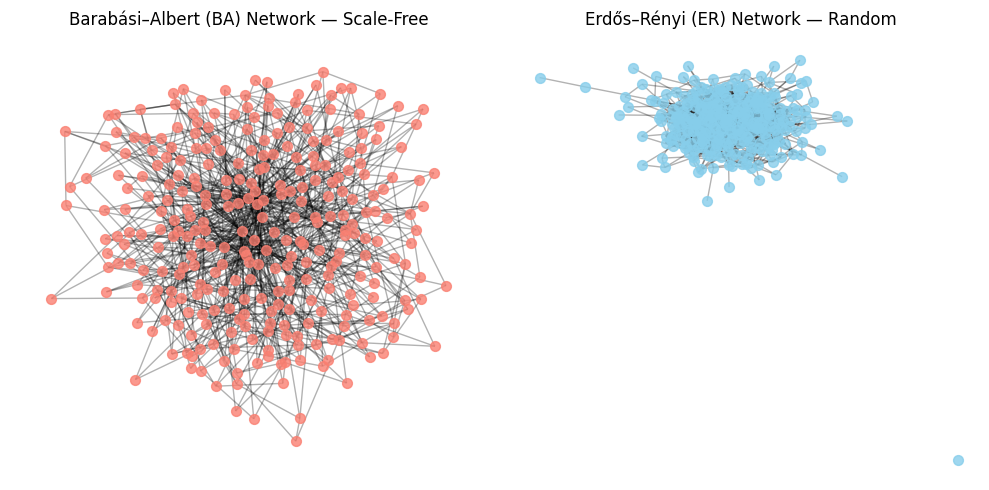

In [5]:
plt.figure(figsize=(10, 5))

# --- Barabási–Albert (scale-free) network ---
plt.subplot(1, 2, 1)
pos_ba = nx.spring_layout(G_ba, seed=42)  # force-directed layout for nice visualization
nx.draw_networkx_nodes(G_ba, pos_ba, node_size=50, node_color="salmon", alpha=0.8)
nx.draw_networkx_edges(G_ba, pos_ba, alpha=0.3)
plt.title("Barabási–Albert (BA) Network — Scale-Free")
plt.axis("off")

# --- Erdős–Rényi (random) network ---
plt.subplot(1, 2, 2)
pos_er = nx.spring_layout(G_er, seed=42)
nx.draw_networkx_nodes(G_er, pos_er, node_size=50, node_color="skyblue", alpha=0.8)
nx.draw_networkx_edges(G_er, pos_er, alpha=0.3)
plt.title("Erdős–Rényi (ER) Network — Random")
plt.axis("off")

plt.tight_layout()
plt.show()

As we probably expected, in the BA network, nodes gravitate visually toward a few high-degree hubs.
In the ER network, on the other hand, there’s no dominant node — connections look random and diffuse. Let's see this with more "hard data" by computing some metrics:

In [11]:
# --- Compute basic metrics ---
def summarize_network(G, name):
    avg_deg = np.mean([d for _, d in G.degree()])
    clustering = nx.average_clustering(G)
    density = nx.density(G)
    print(f"{name} network")
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"Average degree: {avg_deg:.2f}")
    print(f"Density: {density:.4f}")
    print(f"Average clustering coefficient: {clustering:.3f}\n")

summarize_network(G_ba, "Barabási–Albert (BA)")
summarize_network(G_er, "Erdős–Rényi (ER)")

Barabási–Albert (BA) network
Nodes: 300, Edges: 891
Average degree: 5.94
Density: 0.0199
Average clustering coefficient: 0.073

Erdős–Rényi (ER) network
Nodes: 300, Edges: 894
Average degree: 5.96
Density: 0.0199
Average clustering coefficient: 0.018



Also, in terms of degree distribution:

In [13]:
# --- Degree distributions ---
def degree_distribution(G):
    degrees = [d for _, d in G.degree()]
    cnt = Counter(degrees)
    k, freq = zip(*sorted(cnt.items()))
    pk = np.array(freq) / sum(freq)
    return np.array(k), pk

k_ba, pk_ba = degree_distribution(G_ba)
k_er, pk_er = degree_distribution(G_er)

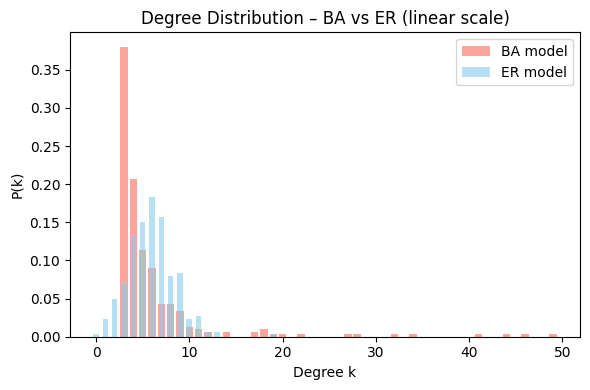

In [16]:
# --- Plot ---
plt.figure(figsize=(6,4))
plt.bar(k_ba, pk_ba, width=0.8, alpha=0.7, label="BA model", color="salmon")
plt.bar(k_er, pk_er, width=0.6, alpha=0.6, label="ER model", color="skyblue")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("Degree Distribution – BA vs ER (linear scale)")
plt.legend()
plt.tight_layout()
plt.show()

Finally, we can verify the **power-law** in the BA model. That is, the probability of a node having degree $k$ decays as a power of $k$:

$$
P(k) \sim k^{-\gamma}
$$

where $\gamma$ is the **power-law exponent**.

Unlike the bell-shaped (Poisson) distribution of random networks (ER), the power-law form has a **heavy tail**:
- Most nodes have few links.
- A few nodes — the **hubs** — have extremely high connectivity.

Let's check this in our synthetic network:

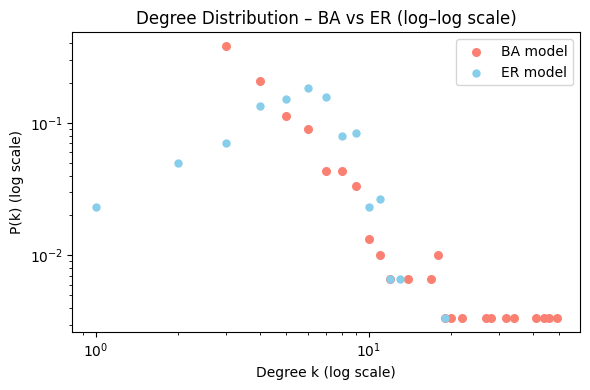

In [18]:
# --- Plot: Log–log scale ---
plt.figure(figsize=(6,4))
plt.scatter(k_ba, pk_ba, s=30, label="BA model", color="salmon")
plt.scatter(k_er, pk_er, s=25, label="ER model", color="skyblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("P(k) (log scale)")
plt.title("Degree Distribution – BA vs ER (log–log scale)")
plt.legend()
plt.tight_layout()
plt.show()

## **4. Conclusion**

Well done! In this lesson we have advanced our understanding from purely random network models to one that tries to explain why **hubs** appear in real-life networks as a function of growth and preferential attachment. 

In the next lesson, we will see a real life implementation of such a model!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
